# Extracting MET4A Pickle Data

All the code is in the met4a package, so we can import it here

In [1]:
from met4a import *

We can use the load_pickle function to load the data of a single pickle file into a dictionary

In [2]:
path = "/workspaces/met4a_data/2026_02_12/1770931655.952085.met4a.pkl"
data_dict = load_pickle(path)

data_dict.keys()

dict_keys(['start_time', 'ref_pressure', 'scale_fac', 'nsamp', 'times', 'pressure', 'temp', 'rh'])

We can also use the load_all_pickles function to load all pickle files in a directory into a list of dictionaries

In [3]:
directory = "/workspaces/met4a_data/2026_02_12/"
data_list = load_all_pickles(directory)
print(len(data_list))
data_list[0].keys()

449


dict_keys(['start_time', 'ref_pressure', 'scale_fac', 'nsamp', 'times', 'pressure', 'temp', 'rh'])

The function dict_to_df can be used to convert a dictionary into a pandas DataFrame

In [4]:
df = dict_to_df(data_dict)
df.head()

,start_time,ref_pressure,scale_fac,nsamp,times,pressure,temp,rh
0,1.770932e+09,40.059721,64.0,1000,0.030186,0.000012,4.39,71.8
1,1.770932e+09,40.059721,64.0,1000,0.045316,-0.000017,4.39,71.8
2,1.770932e+09,40.059721,64.0,1000,0.061831,-0.000003,4.39,71.8
3,1.770932e+09,40.059721,64.0,1000,0.078272,-0.000008,4.39,71.8
4,1.770932e+09,40.059721,64.0,1000,0.093379,-0.000056,4.39,71.8


To quickly convert all dictionaries in the list to DataFrames, we can use a list comprehension

In [ ]:
df_list = [dict_to_df(d) for d in data_list]
print(len(df_list))
df_list[0].head()

449


,start_time,ref_pressure,scale_fac,nsamp,times,pressure,temp,rh
0,1.770932e+09,40.059721,64.0,1000,0.030186,0.000012,4.39,71.8
1,1.770932e+09,40.059721,64.0,1000,0.045316,-0.000017,4.39,71.8
2,1.770932e+09,40.059721,64.0,1000,0.061831,-0.000003,4.39,71.8
3,1.770932e+09,40.059721,64.0,1000,0.078272,-0.000008,4.39,71.8
4,1.770932e+09,40.059721,64.0,1000,0.093379,-0.000056,4.39,71.8


## Coalescing Data Samples

We can coalesce many data samples into one large sample

In [1]:
from met4a import *

directory_path = "/workspaces/met4a_data/2026_02_12"
data_list = load_all_pickles(directory_path)

coalesce_time = []
coalesce_pressure = []
for data in data_list:
    # Convert the time axis to datetime format using the inbuilt function from met4a
    time_axis = convert_to_datetime(data['start_time'], data['times'])
    coalesce_time.append(time_axis)
    coalesce_pressure.append(data['pressure'])

In [10]:
coalesce_time[0][0]

Timestamp('2026-02-12 21:27:35.982270956')

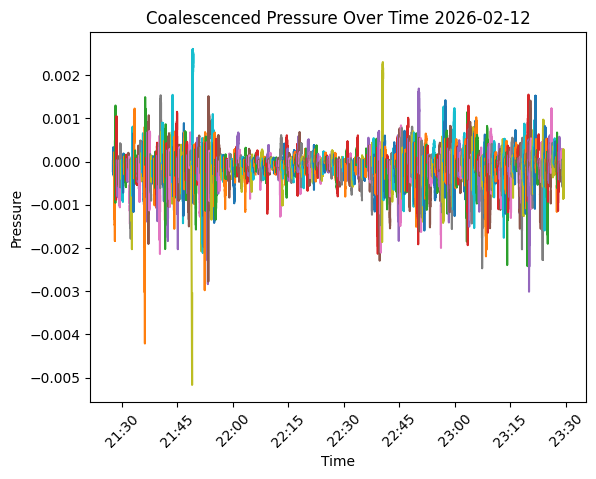

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()

for idx in range(len(coalesce_time)):
    ax.plot(coalesce_time[idx], coalesce_pressure[idx], label=f"Dataset {idx+1}")

date_str = time_axis[0].strftime('%Y-%m-%d')
plt.title(f"Coalescenced Pressure Over Time {date_str}")
plt.xlabel("Time")
plt.ylabel("Pressure")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45);